In [ ]:
# Load tox21.csv and do a quick peek
import pandas as pd

file_path = '/content/tox21.csv'
df_tox = pd.read_csv(file_path)

print(df_tox.head())
print(df_tox.shape)
print(df_tox.columns.tolist())

   NR-AR  NR-AR-LBD  NR-AhR  NR-Aromatase  NR-ER  NR-ER-LBD  NR-PPAR-gamma  \
0    0.0        0.0     1.0           NaN    NaN        0.0            0.0   
1    0.0        0.0     0.0           0.0    0.0        0.0            0.0   
2    NaN        NaN     NaN           NaN    NaN        NaN            NaN   
3    0.0        0.0     0.0           0.0    0.0        0.0            0.0   
4    0.0        0.0     0.0           0.0    0.0        0.0            0.0   

   SR-ARE  SR-ATAD5  SR-HSE  SR-MMP  SR-p53    mol_id  \
0     1.0       0.0     0.0     0.0     0.0   TOX3021   
1     NaN       0.0     NaN     0.0     0.0   TOX3020   
2     0.0       NaN     0.0     NaN     NaN   TOX3024   
3     NaN       0.0     NaN     0.0     0.0   TOX3027   
4     0.0       0.0     0.0     0.0     0.0  TOX20800   

                                              smiles  
0                       CCOc1ccc2nc(S(N)(=O)=O)sc2c1  
1                          CCN1C(=O)NC(c2ccccc2)C1=O  
2  CC[C@]1(O)CC[C@H]2[C

In [ ]:
# !pip install rdkit-pypi
# !apt-get update
# !apt-get install -y python3-rdkit
# !pip install rdkit

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,945 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,842 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,951 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:14 http://archive.ubuntu.com

In [ ]:
# Re-import RDKit after installation and featurize: interpretable descriptors + Morgan fingerprints

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.Chem import AllChem, DataStructs

assay_cols = [
    'NR-AR','NR-AR-LBD','NR-AhR','NR-Aromatase','NR-ER','NR-ER-LBD','NR-PPAR-gamma',
    'SR-ARE','SR-ATAD5','SR-HSE','SR-MMP','SR-p53'
]

assay_df = df_tox[assay_cols].apply(pd.to_numeric, errors='coerce')
non_missing_counts = assay_df.notna().sum(axis=1)
any_positive = (assay_df.fillna(0) > 0).any(axis=1).astype(int)

# Working modeling table
model_base_df = df_tox[['mol_id','smiles']].copy()
model_base_df['non_missing_assays'] = non_missing_counts
model_base_df['tox_any'] = any_positive
model_base_df = model_base_df[model_base_df['non_missing_assays'] > 0].reset_index(drop=True)

# Interpretable descriptors
descriptor_names = [
    'MolWt','MolLogP','TPSA','NumHDonors','NumHAcceptors','NumRotatableBonds',
    'RingCount','NumAromaticRings','HeavyAtomCount','FractionCSP3'
]

def calc_descriptors(smiles_str):
    mol = Chem.MolFromSmiles(smiles_str)
    if mol is None:
        return None
    vals = {
        'MolWt': Descriptors.MolWt(mol),
        'MolLogP': Descriptors.MolLogP(mol),
        'TPSA': rdMolDescriptors.CalcTPSA(mol),
        'NumHDonors': rdMolDescriptors.CalcNumHBD(mol),
        'NumHAcceptors': rdMolDescriptors.CalcNumHBA(mol),
        'NumRotatableBonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
        'RingCount': rdMolDescriptors.CalcNumRings(mol),
        'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol),
        'HeavyAtomCount': mol.GetNumHeavyAtoms(),
        'FractionCSP3': rdMolDescriptors.CalcFractionCSP3(mol)
    }
    return vals

# Structure fingerprints
fp_bits = 2048
fp_radius = 2

def calc_morgan_fp(smiles_str, n_bits=2048, radius=2):
    mol = Chem.MolFromSmiles(smiles_str)
    if mol is None:
        return None

    generator = GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = generator.GetFingerprint(mol)
    # fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# Featurize
valid_rows = []
desc_rows = []
fp_rows = []

for idx, smi in enumerate(tqdm(model_base_df['smiles'].tolist(), desc='Featurizing')):
    d = calc_descriptors(smi)
    fp = calc_morgan_fp(smi, n_bits=fp_bits, radius=fp_radius)
    ok = (d is not None) and (fp is not None)
    valid_rows.append(ok)
    if ok:
        desc_rows.append(d)
        fp_rows.append(fp)

valid_rows = np.array(valid_rows)
model_df = model_base_df[valid_rows].reset_index(drop=True)
desc_df = pd.DataFrame(desc_rows)
fp_mat = np.vstack(fp_rows)

# Combine into one feature matrix
X_desc = desc_df[descriptor_names].copy()
X_fp = pd.DataFrame(fp_mat, columns=["FP_" + str(i) for i in range(fp_bits)])
X_all = pd.concat([X_desc, X_fp], axis=1)
y = model_df['tox_any'].astype(int).values

print(model_df.head())
print(X_desc.head())
print('X_all shape')
print(X_all.shape)
print('Positive rate')
print(pd.Series(y).value_counts(normalize=True).sort_index().round(3))

Featurizing:   0%|          | 0/7831 [00:00<?, ?it/s]

[08:18:14] WARNING: not removing hydrogen atom without neighbors
[08:18:14] WARNING: not removing hydrogen atom without neighbors
[08:18:16] Explicit valence for atom # 8 Al, 6, is greater than permitted
[08:18:16] Explicit valence for atom # 8 Al, 6, is greater than permitted
[08:18:17] Explicit valence for atom # 3 Al, 6, is greater than permitted
[08:18:17] Explicit valence for atom # 3 Al, 6, is greater than permitted
[08:18:17] Explicit valence for atom # 4 Al, 6, is greater than permitted
[08:18:17] Explicit valence for atom # 4 Al, 6, is greater than permitted
[08:18:19] Explicit valence for atom # 4 Al, 6, is greater than permitted
[08:18:19] Explicit valence for atom # 4 Al, 6, is greater than permitted
[08:18:21] Explicit valence for atom # 9 Al, 6, is greater than permitted
[08:18:21] Explicit valence for atom # 9 Al, 6, is greater than permitted
[08:18:21] Explicit valence for atom # 5 Al, 6, is greater than permitted
[08:18:21] Explicit valence for atom # 5 Al, 6, is great

     mol_id                                             smiles  \
0   TOX3021                       CCOc1ccc2nc(S(N)(=O)=O)sc2c1   
1   TOX3020                          CCN1C(=O)NC(c2ccccc2)C1=O   
2   TOX3024  CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...   
3   TOX3027                    CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C   
4  TOX20800                          CC(O)(P(=O)(O)O)P(=O)(O)O   

   non_missing_assays  tox_any  
0                  10        1  
1                  10        0  
2                   2        0  
3                  10        0  
4                  12        0  
     MolWt  MolLogP    TPSA  NumHDonors  NumHAcceptors  NumRotatableBonds  \
0  258.324  1.34240   82.28           1              5                  3   
1  204.229  1.29940   49.41           1              2                  2   
2  288.475  5.09030   20.23           1              1                  1   
3  276.424  3.75244   32.34           1              2                  7   
4  206.027 -0.99220 

In [ ]:
# Train/test split + baseline models
# We'll train two models:
# 1) Logistic Regression on interpretable RDKit descriptors (for easy interpretation)
# 2) LightGBM on descriptors + fingerprints (for stronger predictive performance)

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_all, y, np.arange(len(y)), test_size=0.2, random_state=42, stratify=y
)

# Descriptor-only view
Xdesc_train = X_train[descriptor_names]
Xdesc_test = X_test[descriptor_names]

lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=None))
])

lr_pipe.fit(Xdesc_train, y_train)

proba_lr = lr_pipe.predict_proba(Xdesc_test)[:, 1]
roc_lr = roc_auc_score(y_test, proba_lr)
ap_lr = average_precision_score(y_test, proba_lr)

print('LogReg (descriptors) ROC-AUC')
print(round(roc_lr, 4))
print('LogReg (descriptors) PR-AUC')
print(round(ap_lr, 4))

# Calibrated threshold at 0.5 for a quick report
pred_lr = (proba_lr >= 0.5).astype(int)
print(classification_report(y_test, pred_lr, digits=3))

LogReg (descriptors) ROC-AUC
0.712
LogReg (descriptors) PR-AUC
0.5626
              precision    recall  f1-score   support

           0      0.776     0.643     0.703       991
           1      0.524     0.679     0.592       574

    accuracy                          0.656      1565
   macro avg      0.650     0.661     0.647      1565
weighted avg      0.684     0.656     0.662      1565



In [ ]:
# LightGBM model on descriptors + fingerprints for better performance

import importlib
lgb_spec = importlib.util.find_spec('lightgbm')
print(lgb_spec)

if lgb_spec is None:
    %pip -q install lightgbm
    print('installed')
else:
    print('already installed')

from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score

imputer_all = SimpleImputer(strategy='median')
Xtr_imp = imputer_all.fit_transform(X_train)
Xte_imp = imputer_all.transform(X_test)

lgb = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.4,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

lgb.fit(Xtr_imp, y_train)
proba_lgb = lgb.predict_proba(Xte_imp)[:, 1]

roc_lgb = roc_auc_score(y_test, proba_lgb)
ap_lgb = average_precision_score(y_test, proba_lgb)

print('LightGBM (desc+FP) ROC-AUC')
print(round(roc_lgb, 4))
print('LightGBM (desc+FP) PR-AUC')
print(round(ap_lgb, 4))

ModuleSpec(name='lightgbm', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7fc7bad1b2f0>, origin='/usr/local/lib/python3.12/dist-packages/lightgbm/__init__.py', submodule_search_locations=['/usr/local/lib/python3.12/dist-packages/lightgbm'])
already installed
[LightGBM] [Info] Number of positive: 2295, number of negative: 3963
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.064060 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4435
[LightGBM] [Info] Number of data points in the train set: 6258, number of used features: 1648
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM (desc+FP) ROC-AUC
0.7734
LightGBM (desc+FP) PR-AUC
0.7177


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


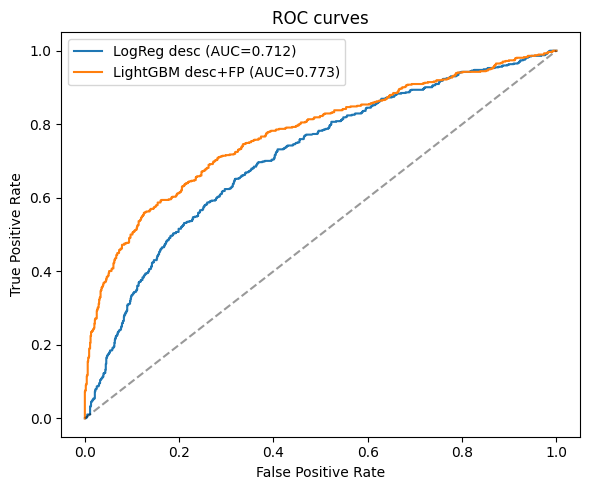

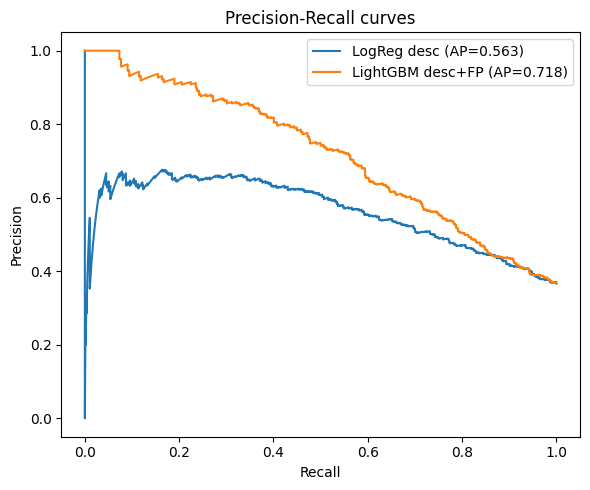

             feature      coef  abs_coef
1            MolLogP  0.997896  0.997896
8     HeavyAtomCount -0.836995  0.836995
4      NumHAcceptors  0.443987  0.443987
0              MolWt  0.440151  0.440151
9       FractionCSP3 -0.388934  0.388934
6          RingCount  0.312395  0.312395
3         NumHDonors  0.271744  0.271744
5  NumRotatableBonds -0.225059  0.225059
7   NumAromaticRings -0.126388  0.126388
2               TPSA  0.090786  0.090786


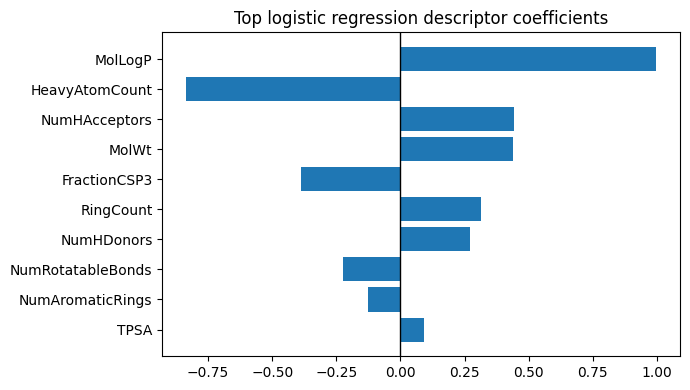

             feature  gain
1            MolLogP  2791
0              MolWt  2473
2               TPSA  2048
9       FractionCSP3  1708
8     HeavyAtomCount  1408
5  NumRotatableBonds  1017
4      NumHAcceptors   740
3         NumHDonors   511
6          RingCount   500
7   NumAromaticRings   265


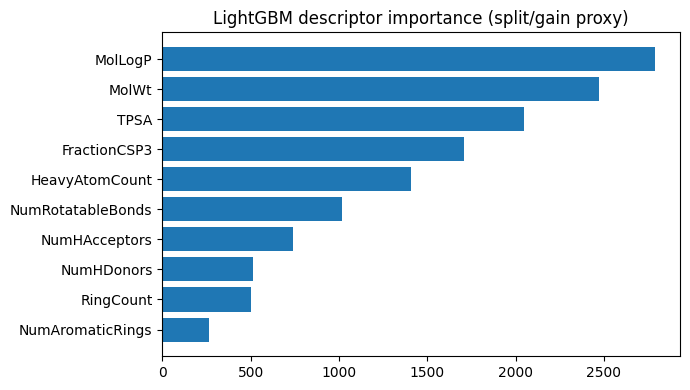

In [ ]:
# Visualize model performance and interpretability

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, precision_recall_curve

# ROC + PR curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, proba_lr)

fpr_lgb, tpr_lgb, _ = roc_curve(y_test, proba_lgb)
prec_lgb, rec_lgb, _ = precision_recall_curve(y_test, proba_lgb)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label='LogReg desc (AUC=' + str(round(roc_lr,3)) + ')')
plt.plot(fpr_lgb, tpr_lgb, label='LightGBM desc+FP (AUC=' + str(round(roc_lgb,3)) + ')')
plt.plot([0,1],[0,1],'k--',alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
plt.plot(rec_lr, prec_lr, label='LogReg desc (AP=' + str(round(ap_lr,3)) + ')')
plt.plot(rec_lgb, prec_lgb, label='LightGBM desc+FP (AP=' + str(round(ap_lgb,3)) + ')')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curves')
plt.legend()
plt.tight_layout()
plt.show()

# Descriptor feature importance from logistic regression
clf_lr = lr_pipe.named_steps['clf']
coef_df = pd.DataFrame({'feature': descriptor_names, 'coef': clf_lr.coef_.ravel()})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)
print(coef_df)

plt.figure(figsize=(7,4))
plot_df = coef_df.head(10).iloc[::-1]
plt.barh(plot_df['feature'], plot_df['coef'])
plt.axvline(0, color='k', linewidth=1)
plt.title('Top logistic regression descriptor coefficients')
plt.tight_layout()
plt.show()

# LightGBM importance: focus on descriptors only (more interpretable)
feat_names = list(X_all.columns)
imp_df = pd.DataFrame({'feature': feat_names, 'gain': lgb.feature_importances_})
imp_desc = imp_df[imp_df['feature'].isin(descriptor_names)].sort_values('gain', ascending=False)
print(imp_desc)

plt.figure(figsize=(7,4))
plot_imp = imp_desc.head(10).iloc[::-1]
plt.barh(plot_imp['feature'], plot_imp['gain'])
plt.title('LightGBM descriptor importance (split/gain proxy)')
plt.tight_layout()
plt.show()

# What I did (and what “tox_any” means)
I treated this as a binary toxicity prediction task where the label tox_any is 1 if a molecule is positive in at least one of the available Tox21 assays (among the 12 targets), and 0 otherwise. Because Tox21 has lots of missing assay readouts per molecule, I also computed non_missing_assays as a sanity check on label coverage.

You’ve got 7,831 molecules and a positive rate of ~0.367 (so not crazy imbalanced, but not 50/50 either).

# Model 1: Logistic Regression on RDKit descriptors (interpretable baseline)
I trained a LogisticRegression on a small, interpretable RDKit descriptor set:

MolWt, MolLogP, TPSA, NumHDonors, NumHAcceptors, NumRotatableBonds, RingCount, NumAromaticRings, HeavyAtomCount, FractionCSP3
# Using an 80/20 stratified split:

ROC-AUC = 0.7142
PR-AUC = 0.5509
At a naive 0.5 threshold, it leans toward catching toxics (higher recall) at the expense of precision, which is typical with class_weight='balanced'.

# What the coefficients say (directionally)
# The strongest signals in the logistic model were:

MolLogP (positive coefficient): more hydrophobic compounds trend more likely “tox_any”
HeavyAtomCount (negative coefficient): after controlling for other descriptors, larger/heavier atoms count pushes slightly toward non-toxic (this can happen because it’s correlated with other size measures like MolWt, so signs can be “adjusted” in multivariate ways)
NumHAcceptors, MolWt (positive): more acceptors / bigger weight slightly increases predicted tox_any
FractionCSP3 (negative): more sp3 character trends less tox_any
This is not “causal”, but it’s a useful, interpretable baseline.

# Model 2: LightGBM on descriptors + Morgan fingerprint bits (stronger model)
Then I trained a LightGBM classifier on the full feature set X_all which (from earlier steps) is:

# RDKit descriptors + fingerprints
Shape was (7831, 2058)
Performance on the same split:

ROC-AUC = 0.7496
PR-AUC = 0.6732
So compared to logistic regression, LightGBM gives a meaningful lift, especially on PR-AUC (which matters a lot when positives aren’t super common).

Visuals I generated
I plotted:

ROC curves (LogReg vs LightGBM)
Precision–Recall curves (LogReg vs LightGBM)
Top logistic regression coefficients (descriptor interpretability)
Top LightGBM descriptor importances (restricted to descriptors so it’s readable)
The LightGBM PR curve should sit noticeably above the logistic one over most recall values, which matches the AP jump (~0.55 → ~0.67).

# Practical takeaway
If your goal is best predictive performance, the LightGBM (descriptors + FP) is the better model here (higher ROC-AUC and much higher PR-AUC).

If your goal is interpretability / quick chemical intuition, the logistic regression on descriptors is solid and gives you readable drivers (LogP, TPSA, etc.), but it leaves performance on the table.